# Day 4 — The Real Cycle, Drawn on the P-H Map
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** the four points from Day 2 are joined into a loop with four straight legs, each one a real physical process happening inside the refrigerator:

- **1→2 (compression):** cold low-pressure vapour gets squeezed by the compressor into hot high-pressure vapour
- **2→3 (condensation):** that hot vapour gives up heat to the kitchen air and turns into liquid
- **3→4 (expansion):** liquid drops pressure suddenly through the capillary tube, flashing partly into vapour and cooling sharply
- **4→1 (evaporation):** the cold liquid/vapour mix absorbs heat from inside the cabin, finishing as vapour again — and the loop repeats

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Cycle state points: R134a | T_evap=-20C | T_cond=40C
refrigerant = "R134a"
T_evap = -20 + 273.15
T_cond =  40 + 273.15

P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)

h1 = CP.PropsSI("H","P",P_evap,"Q",1,refrigerant)/1000
s1 = CP.PropsSI("S","P",P_evap,"Q",1,refrigerant)
h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)/1000
h3 = CP.PropsSI("H","P",P_cond,"Q",0,refrigerant)/1000
h4 = h3

COP = (h1-h4)/(h2-h1)
print(f"COP: {COP:.3f}")
print(f"State points: h1={h1:.1f}  h2={h2:.1f}  h3={h3:.1f}  h4={h4:.1f} kJ/kg")

COP: 3.064
State points: h1=386.6  h2=429.0  h3=256.4  h4=256.4 kJ/kg


In [4]:
# CELL 4 — Saturation dome (same construction as Day 3)
T_min  = CP.PropsSI("Tmin",  refrigerant) + 5
T_crit = CP.PropsSI("Tcrit", refrigerant) - 0.1
T_range = np.linspace(T_min, T_crit, 300)

h_liq = [CP.PropsSI("H","T",T,"Q",0,refrigerant)/1000 for T in T_range]
P_liq = [CP.PropsSI("P","T",T,"Q",0,refrigerant)/1e5  for T in T_range]
h_vap = [CP.PropsSI("H","T",T,"Q",1,refrigerant)/1000 for T in T_range]
P_vap = [CP.PropsSI("P","T",T,"Q",1,refrigerant)/1e5  for T in T_range]

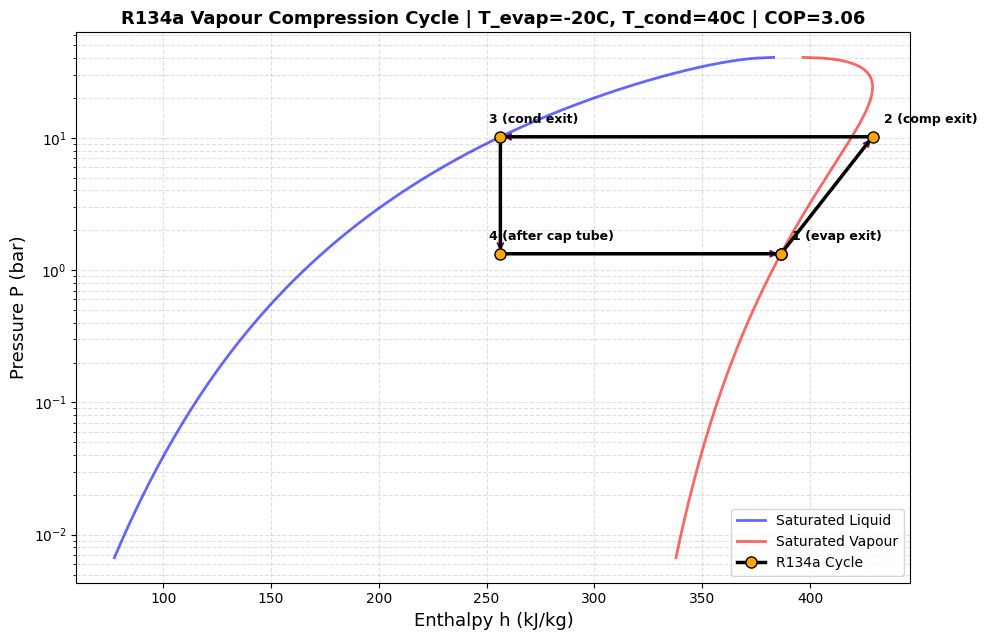

In [5]:
# CELL 5 — Overlay the cycle on the dome (this is the chart Day 4 was missing)
P_evap_bar = P_evap/1e5
P_cond_bar = P_cond/1e5

cycle_h = [h1, h2, h3, h4, h1]
cycle_P = [P_evap_bar, P_cond_bar, P_cond_bar, P_evap_bar, P_evap_bar]

fig, ax = plt.subplots(figsize=(10,6.5))
ax.plot(h_liq, P_liq, "b-", linewidth=2, alpha=0.6, label="Saturated Liquid")
ax.plot(h_vap, P_vap, "r-", linewidth=2, alpha=0.6, label="Saturated Vapour")
ax.plot(cycle_h, cycle_P, "k-", linewidth=2.5, marker="o", markersize=8,
        markerfacecolor="orange", zorder=5, label="R134a Cycle")

labels = ["1 (evap exit)", "2 (comp exit)", "3 (cond exit)", "4 (after cap tube)"]
offsets = [(8, 0.15), (8, 0), (-8, 0.15), (-8, -0.3)]
points = [(h1, P_evap_bar), (h2, P_cond_bar), (h3, P_cond_bar), (h4, P_evap_bar)]
for (hx, Px), lbl, (dx, dy) in zip(points, labels, offsets):
    ax.annotate(lbl, (hx, Px), textcoords="offset points", xytext=(dx, 10),
                fontsize=9, fontweight="bold")

ax.annotate("", xy=(h2, P_cond_bar), xytext=(h1, P_evap_bar),
            arrowprops=dict(arrowstyle="->", color="purple", lw=1.5))
ax.annotate("", xy=(h3, P_cond_bar), xytext=(h2, P_cond_bar),
            arrowprops=dict(arrowstyle="->", color="purple", lw=1.5))
ax.annotate("", xy=(h4, P_evap_bar), xytext=(h3, P_cond_bar),
            arrowprops=dict(arrowstyle="->", color="purple", lw=1.5))
ax.annotate("", xy=(h1, P_evap_bar), xytext=(h4, P_evap_bar),
            arrowprops=dict(arrowstyle="->", color="purple", lw=1.5))

ax.set_yscale("log")
ax.set_xlabel("Enthalpy h (kJ/kg)", fontsize=13)
ax.set_ylabel("Pressure P (bar)", fontsize=13)
ax.set_title(f"R134a Vapour Compression Cycle | T_evap=-20C, T_cond=40C | COP={COP:.2f}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("day04_cycle_ph.png", dpi=150)
plt.show()

**What this graph tells us:** the rectangle-ish loop is the whole refrigeration cycle in one picture. The **top leg (2→3)** sits at the high condenser pressure — that's where heat is dumped to the kitchen. The **bottom leg (4→1)** sits at the low evaporator pressure — that's where heat is absorbed from the cabin. The **horizontal distance** of the bottom leg is the refrigerating effect (cooling delivered per kg); the **horizontal distance** of the left leg (1→2) is the compressor work (electricity spent per kg). COP is simply the ratio of those two distances — visually, a "wide, short" cycle is more efficient than a "narrow, tall" one.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day04_cycle_ph.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 04 - cycle overlaid on P-H diagram (adds missing chart)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 04 - cycle overlaid on P-H diagram (adds missing chart)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
